In [ ]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")

PyTorch version : 2.10.0+cu128
CUDA available  : True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

COMBINED_DIR       = "/content/drive/MyDrive/combined_dataset/train"
REALWORLD_TEST_DIR = "/content/drive/MyDrive/realworld_test"

SELECTED_CLASSES = [
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___healthy",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato___Leaf_Mold",
]

IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_EPOCHS    = 20
LEARNING_RATE = 0.001
NUM_CLASSES   = len(SELECTED_CLASSES)
RANDOM_SEED   = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device     : {DEVICE}")
print(f"Classes    : {NUM_CLASSES}")
print(f"Class list : {SELECTED_CLASSES}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device     : cuda
Classes    : 5
Class list : ['Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Leaf_Mold']


In [ ]:
baseline_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # ImageNet statistics
        std =[0.229, 0.224, 0.225]
    )
])

# Eval transforms used for validation, test, and real-world test
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225]
    )
])

In [ ]:
full_dataset = datasets.ImageFolder(
    root=COMBINED_DIR,
    transform=baseline_transforms
)

# Build a label remap so only our 5 classes remain with indices 0–4
selected_idx = [full_dataset.class_to_idx[c] for c in SELECTED_CLASSES]
label_remap  = {old: new for new, old in enumerate(selected_idx)}

filtered_samples = [
    (path, label_remap[label])
    for path, label in full_dataset.samples
    if label in selected_idx
]

# Overwrite the dataset internals with filtered data
full_dataset.samples      = filtered_samples
full_dataset.targets      = [l for _, l in filtered_samples]
full_dataset.classes      = SELECTED_CLASSES
full_dataset.class_to_idx = {c: i for i, c in enumerate(SELECTED_CLASSES)}

print(f"Total images after filtering: {len(full_dataset)}")
print()
for cls in SELECTED_CLASSES:
    idx   = full_dataset.class_to_idx[cls]
    count = sum(1 for _, l in full_dataset.samples if l == idx)
    print(f"  {cls:<52} {count:>5} images")

Total images after filtering: 11356

  Tomato___Early_blight                                 1079 images
  Tomato___Late_blight                                  2010 images
  Tomato___healthy                                      1650 images
  Tomato___Tomato_Yellow_Leaf_Curl_Virus                5580 images
  Tomato___Leaf_Mold                                    1037 images


In [ ]:
all_indices = list(range(len(full_dataset)))
all_targets = full_dataset.targets

# First split: 70% train, 30% temp
train_idx, temp_idx = train_test_split(
    all_indices,
    test_size=0.30,
    stratify=all_targets,
    random_state=RANDOM_SEED
)

# Second split: temp → 50/50 val and test (each 15% of total)
temp_targets = [all_targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=temp_targets,
    random_state=RANDOM_SEED
)

train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_dataset, val_idx)
test_dataset  = Subset(full_dataset, test_idx)

print(f"Train : {len(train_dataset):>5} images")
print(f"Val   : {len(val_dataset):>5} images")
print(f"Test  : {len(test_dataset):>5} images")

Train :  7949 images
Val   :  1703 images
Test  :  1704 images


In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("DataLoaders created.")
print(f"  Train batches : {len(train_loader)}")
print(f"  Val batches   : {len(val_loader)}")
print(f"  Test batches  : {len(test_loader)}")

DataLoaders created.
  Train batches : 249
  Val batches   : 54
  Test batches  : 54


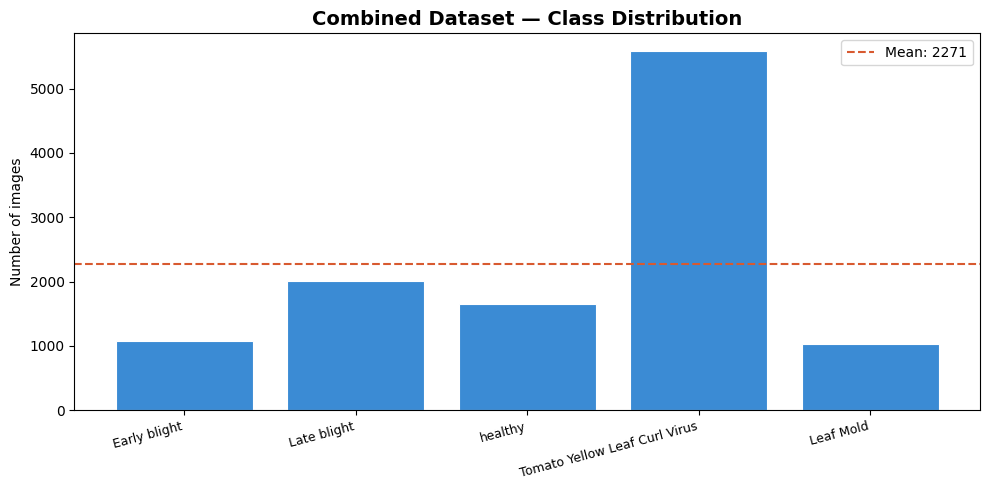

Saved: baseline_class_distribution.png


In [ ]:
from collections import Counter

label_counts = Counter(full_dataset.targets)
class_labels = [cls.replace("Tomato___", "").replace("_", " ") for cls in SELECTED_CLASSES]
counts       = [label_counts[i] for i in range(NUM_CLASSES)]

plt.figure(figsize=(10, 5))
bars = plt.bar(class_labels, counts, color="#3B8BD4", edgecolor="white", linewidth=0.8)
plt.axhline(np.mean(counts), color="#D85A30", linestyle="--",
            label=f"Mean: {np.mean(counts):.0f}")
plt.title("Combined Dataset — Class Distribution", fontsize=14, fontweight="bold")
plt.ylabel("Number of images")
plt.xticks(rotation=15, ha="right", fontsize=9)
plt.legend()
plt.tight_layout()
plt.savefig("baseline_class_distribution.png", dpi=150)
plt.show()
print("Saved: baseline_class_distribution.png")

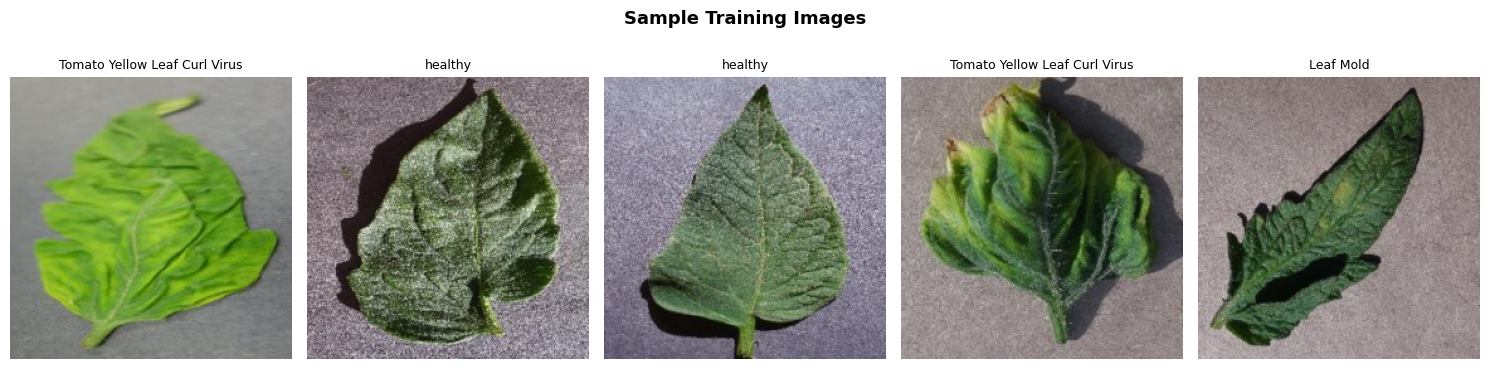

In [ ]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

images, labels = next(iter(train_loader))
images_disp = (images[:5] * std + mean).clamp(0, 1)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.imshow(images_disp[i].permute(1, 2, 0).numpy())
    cls_name = SELECTED_CLASSES[labels[i]].replace("Tomato___", "").replace("_", " ")
    ax.set_title(cls_name, fontsize=9, wrap=True)
    ax.axis("off")
plt.suptitle("Sample Training Images", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("baseline_sample_images.png", dpi=150)
plt.show()

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(BaselineCNN, self).__init__()

        self.features = nn.Sequential(

            # ── Block 1: 3 → 32 feature maps ─────────────────────────────────
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 224 → 112

            # ── Block 2: 32 → 64 feature maps ────────────────────────────────
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 112 → 56

            # ── Block 3: 64 → 128 feature maps ───────────────────────────────
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 56 → 28

            # ── Block 4: 128 → 256 feature maps ──────────────────────────────
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),                          # 28 → 14
        )

        # Collapse spatial dims to fixed 4×4 regardless of input size
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))   # 14 → 4x4

        self.classifier = nn.Sequential(
            nn.Flatten(),                                # 256*4*4 = 4096
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),                             # mild regularisation
            nn.Linear(512, num_classes)                  # output logits
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x


model = BaselineCNN(num_classes=NUM_CLASSES).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print()
print(model)

Total parameters     : 2,489,605
Trainable parameters : 2,489,605

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), p

In [ ]:
# CrossEntropyLoss: standard for multi-class classification.
# Combines LogSoftmax + NLLLoss internally.
criterion = nn.CrossEntropyLoss()

# Adam: adaptive learning rate optimizer.
# More robust than SGD for training CNNs from scratch.
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ReduceLROnPlateau: halves LR when val accuracy stops improving for 4 epochs.
# Helps the model settle into tighter minima toward end of training.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=4
)

print("Loss      : CrossEntropyLoss")
print("Optimizer : Adam  (lr={})".format(LEARNING_RATE))
print("Scheduler : ReduceLROnPlateau (factor=0.5, patience=4)")

Loss      : CrossEntropyLoss
Optimizer : Adam  (lr=0.001)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=4)


In [ ]:
try:
    from tqdm.notebook import tqdm
except:
    from tqdm import tqdm

history = {
    "train_loss": [], "train_acc": [],
    "val_loss"  : [], "val_acc"  : [],
    "lr"        : []
}

best_val_acc = 0.0
best_epoch   = 0


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    pbar = tqdm(loader, desc="  Training", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

        pbar.set_postfix(loss=f"{running_loss/total:.4f}",
                         acc=f"{100.*correct/total:.1f}%")

    return running_loss / total, 100. * correct / total


def validate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss    = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

    return running_loss / total, 100. * correct / total


print(f"{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | "
      f"{'Val Loss':>8} | {'Val Acc':>8} | {'LR':>8} | {'Time':>6}")
print("-" * 75)

for epoch in range(NUM_EPOCHS):
    start = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss,   val_acc   = validate(model, val_loader, criterion, DEVICE)

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    elapsed = time.time() - start
    print(f"{epoch+1:>6} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
          f"{val_loss:>8.4f} | {val_acc:>7.2f}% | {current_lr:>8.6f} | {elapsed:>5.1f}s")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch   = epoch + 1
        torch.save(model.state_dict(), "baseline_cnn_best.pth")
        print(f"         ✓ Best model saved (val acc: {best_val_acc:.2f}%)")

print(f"\nTraining complete.")
print(f"Best val accuracy : {best_val_acc:.2f}%  at epoch {best_epoch}")

 Epoch | Train Loss | Train Acc | Val Loss |  Val Acc |       LR |   Time
---------------------------------------------------------------------------


  Training:   0%|          | 0/249 [00:00<?, ?it/s]

     1 |     0.5314 |    81.78% |   0.3017 |   88.37% | 0.001000 |  92.2s
         ✓ Best model saved (val acc: 88.37%)


  Training:   0%|          | 0/249 [00:00<?, ?it/s]

     2 |     0.3133 |    88.90% |   0.2206 |   91.90% | 0.001000 |  85.6s
         ✓ Best model saved (val acc: 91.90%)


...

    18 |     0.0721 |    97.53% |   0.1563 |   95.95% | 0.001000 |  84.4s


  Training:   0%|          | 0/249 [00:00<?, ?it/s]

    19 |     0.0805 |    97.36% |   0.1174 |   96.77% | 0.000500 |  84.7s


  Training:   0%|          | 0/249 [00:00<?, ?it/s]

    20 |     0.0409 |    98.55% |   0.0972 |   97.42% | 0.000500 |  84.5s
         ✓ Best model saved (val acc: 97.42%)

Training complete.
Best val accuracy : 97.42%  at epoch 20


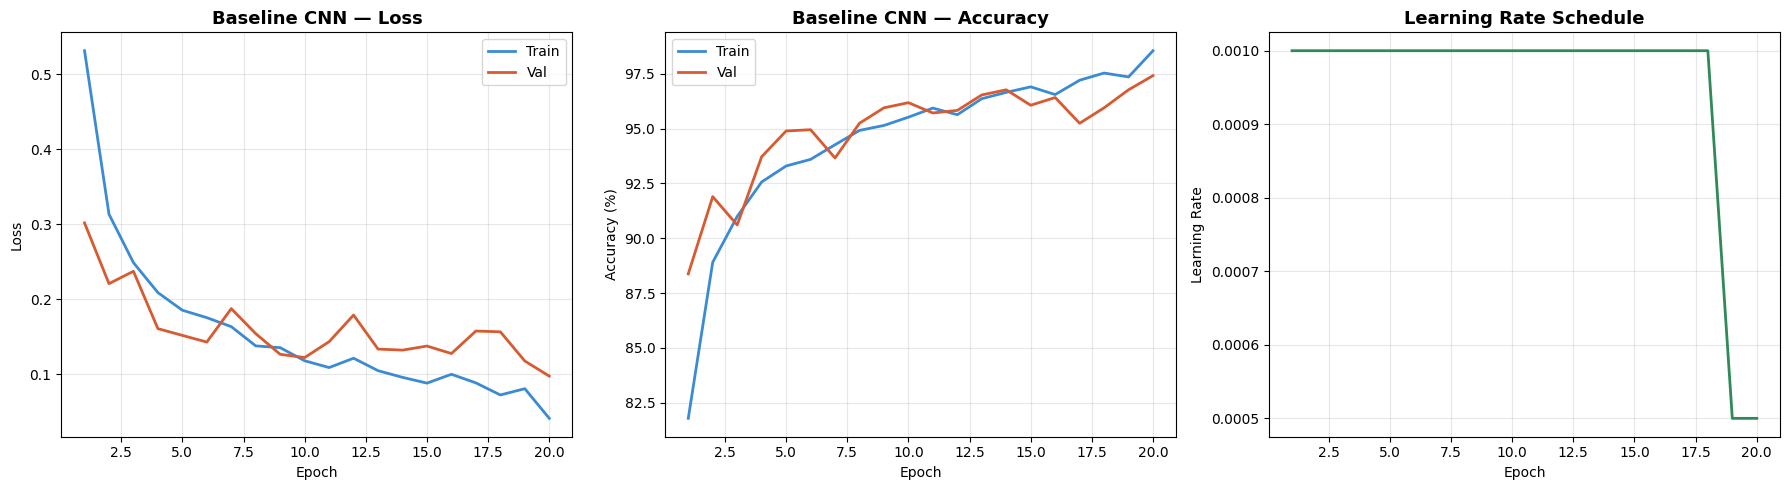

Saved: baseline_training_curves.png


In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(epochs_range, history["train_loss"], label="Train", color="#3B8BD4", linewidth=2)
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   color="#D85A30", linewidth=2)
axes[0].set_title("Baseline CNN — Loss", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history["train_acc"], label="Train", color="#3B8BD4", linewidth=2)
axes[1].plot(epochs_range, history["val_acc"],   label="Val",   color="#D85A30", linewidth=2)
axes[1].set_title("Baseline CNN — Accuracy", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

# Learning rate
axes[2].plot(epochs_range, history["lr"], color="#2E8B57", linewidth=2)
axes[2].set_title("Learning Rate Schedule", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning Rate")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("baseline_training_curves.png", dpi=150)
plt.show()
print("Saved: baseline_training_curves.png")

In [ ]:
# Load best checkpoint
model.load_state_dict(torch.load("baseline_cnn_best.pth", map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = 100. * (all_preds == all_labels).sum() / len(all_labels)
print(f"Baseline CNN — Standard Test Accuracy: {test_acc:.2f}%")
print()

# Shorten class names for readability
short_names = [c.replace("Tomato___", "").replace("_", " ") for c in SELECTED_CLASSES]

print(classification_report(
    all_labels, all_preds,
    target_names=short_names,
    digits=4
))

Baseline CNN — Standard Test Accuracy: 97.54%

                               precision    recall  f1-score   support

                 Early blight     0.9012    0.9568    0.9281       162
                  Late blight     0.9565    0.9470    0.9517       302
                      healthy     0.9880    0.9960    0.9920       248
Tomato Yellow Leaf Curl Virus     0.9964    0.9904    0.9934       837
                    Leaf Mold     0.9603    0.9355    0.9477       155

                     accuracy                         0.9754      1704
                    macro avg     0.9605    0.9651    0.9626      1704
                 weighted avg     0.9758    0.9754    0.9755      1704



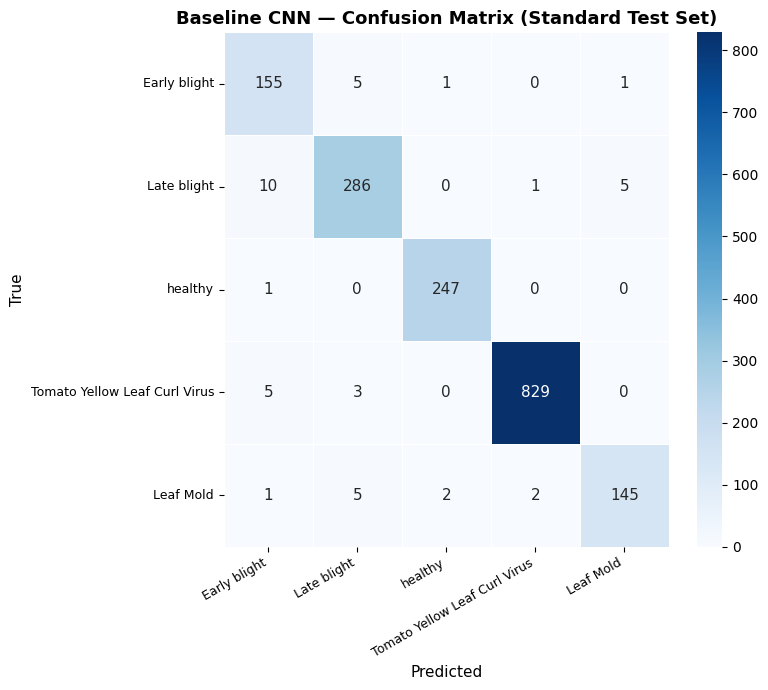

Saved: baseline_confusion_matrix_standard.png


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=short_names,
    yticklabels=short_names,
    linewidths=0.5,
    annot_kws={"size": 11}
)
plt.title("Baseline CNN — Confusion Matrix (Standard Test Set)",
          fontsize=13, fontweight="bold")
plt.xlabel("Predicted", fontsize=11)
plt.ylabel("True",      fontsize=11)
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig("baseline_confusion_matrix_standard.png", dpi=150)
plt.show()
print("Saved: baseline_confusion_matrix_standard.png")

Baseline CNN — Real-World Test Accuracy: 54.17%

                               precision    recall  f1-score   support

                 Early blight     0.6364    0.7778    0.7000         9
                  Late blight     0.4286    0.6000    0.5000        10
                      healthy     0.6667    0.2500    0.3636         8
Tomato Yellow Leaf Curl Virus     0.6667    0.6667    0.6667        15
                    Leaf Mold     0.2000    0.1667    0.1818         6

                     accuracy                         0.5417        48
                    macro avg     0.5197    0.4922    0.4824        48
                 weighted avg     0.5530    0.5417    0.5271        48



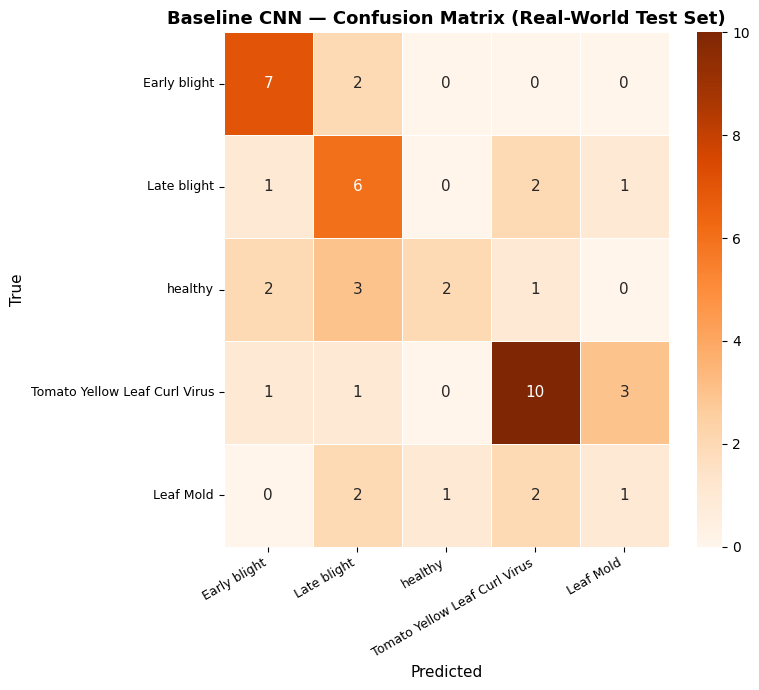

Saved: baseline_confusion_matrix_realworld.png


In [ ]:
if not os.path.exists(REALWORLD_TEST_DIR):
    print("Real-world test directory not found — skipping.")
    print(f"Expected at: {REALWORLD_TEST_DIR}")
else:
    realworld_dataset = datasets.ImageFolder(
        root=REALWORLD_TEST_DIR,
        transform=eval_transforms
    )

    # Enforce same class mapping as training set
    realworld_dataset.class_to_idx = {c: i for i, c in enumerate(SELECTED_CLASSES)}
    realworld_dataset.classes       = SELECTED_CLASSES
    realworld_dataset.samples = [
        (p, realworld_dataset.class_to_idx[os.path.basename(os.path.dirname(p))])
        for p, _ in realworld_dataset.samples
        if os.path.basename(os.path.dirname(p)) in realworld_dataset.class_to_idx
    ]
    realworld_dataset.targets = [s[1] for s in realworld_dataset.samples]

    realworld_loader = DataLoader(
        realworld_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2
    )

    rw_preds, rw_labels = [], []

    model.eval()
    with torch.no_grad():
        for images, labels in realworld_loader:
            images  = images.to(DEVICE)
            outputs = model(images)
            _, predicted = outputs.max(1)
            rw_preds.extend(predicted.cpu().numpy())
            rw_labels.extend(labels.numpy())

    rw_preds  = np.array(rw_preds)
    rw_labels = np.array(rw_labels)

    rw_acc = 100. * (rw_preds == rw_labels).sum() / len(rw_labels)
    print(f"Baseline CNN — Real-World Test Accuracy: {rw_acc:.2f}%")
    print()
    print(classification_report(
        rw_labels, rw_preds,
        target_names=short_names,
        digits=4
    ))

    # Confusion matrix for real-world test
    rw_cm = confusion_matrix(rw_labels, rw_preds)

    plt.figure(figsize=(8, 7))
    sns.heatmap(
        rw_cm,
        annot=True,
        fmt="d",
        cmap="Oranges",
        xticklabels=short_names,
        yticklabels=short_names,
        linewidths=0.5,
        annot_kws={"size": 11}
    )
    plt.title("Baseline CNN — Confusion Matrix (Real-World Test Set)",
              fontsize=13, fontweight="bold")
    plt.xlabel("Predicted", fontsize=11)
    plt.ylabel("True",      fontsize=11)
    plt.xticks(rotation=30, ha="right", fontsize=9)
    plt.yticks(rotation=0,  fontsize=9)
    plt.tight_layout()
    plt.savefig("baseline_confusion_matrix_realworld.png", dpi=150)
    plt.show()
    print("Saved: baseline_confusion_matrix_realworld.png")

In [ ]:
print("=" * 60)
print("BASELINE CNN — FINAL SUMMARY")
print("=" * 60)
print(f"Architecture     : 4-block CNN from scratch")
print(f"Parameters       : {sum(p.numel() for p in model.parameters()):,}")
print(f"Epochs trained   : {NUM_EPOCHS}")
print(f"Best val acc     : {best_val_acc:.2f}%  (epoch {best_epoch})")
print(f"Standard test acc: {test_acc:.2f}%")
print(f"Saved checkpoint : baseline_cnn_best.pth")
print()
print("Output files:")
print("  baseline_class_distribution.png")
print("  baseline_sample_images.png")
print("  baseline_training_curves.png")
print("  baseline_confusion_matrix_standard.png")
print("  baseline_confusion_matrix_realworld.png")
print("  baseline_cnn_best.pth")

BASELINE CNN — FINAL SUMMARY
Architecture     : 4-block CNN from scratch


NameError: name 'model' is not defined